# MCQMC 2026 Plenary Talk Running Example

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vf}{\boldsymbol{f}}
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vu}{\boldsymbol{u}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vy}{\boldsymbol{y}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vmu}{\boldsymbol{\mu}}
\newcommand{\mSigma}{\mathsf{\Sigma}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\Norm}{\operatorname{Norm}}
\newcommand{\GP}{\operatorname{GP}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

We observe noisy function values

$$
Y_i = f(x_i) + \epsilon_i, \qquad 
\epsilon_i \sim \Norm(0,\sigma^2),
\qquad i=1,\ldots,m,
$$

and place a Gaussian process prior on the unknown function,

$$
f \sim \GP(0,K_\theta).
$$

Because the prior and likelihood are Gaussian, the posterior distribution of the vector of latent function values on a grid,

$$
\vf =
\bigl(f(t_1),\ldots,f(t_d)\bigr)^\top,
$$

obeys a multivariate normal,

$$
\vf \mid \vy
\sim
\Norm(\vmu,\mSigma).
$$

The quantity of interest is the posterior probability that the latent function remains below a safety threshold $c$ on the grid:

$$
p
=
\Pr\{ f(t_j) \le c,\ j=1,\ldots,d \mid \vy \}
=
\int_{\mathbb{R}^d}
\mathbb{1}\{\vz \le c\mathbf{1}\}
\,
\phi_d(\vz;\vmu,\mSigma)
\,\dif \vz.
$$

After a transformation from independent uniforms to the posterior Gaussian vector, this becomes an integral over the unit cube,

$$
p
=
\int_{[0,1]^d}
g(\vu)\,\dif \vu.
$$

This single example lets us compare Monte Carlo and quasi-Monte Carlo sampling, study the effect of variable transformations, test randomized error estimation, and later consider refinements such as multilevel or dimension-reduction strategies.

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import qmcpy as qp
import time
import pandas as pd
from IPython.display import display, Markdown

import classlib as cl
import classlib.nbviz as nb

from qmcpy.util import MaxSamplesWarning
import warnings

%matplotlib inline

rng_seed = 20260527
rng = np.random.default_rng(rng_seed)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT
nb.configure(
    figpath="MCQMC26_figures",
    savefigs=True,
    imgfrmt="png",
)

# nb.SAVEFIGS = False;

## Notebook parameters

In [17]:
rng_seed = 20260527

n_obs = 9 #number of observations of the function, i.e., where the data is taken
d_grid = 64 #number of evaluation points along the line, i.e., where I need the function to be under the threshold
d_plot = 512 #number of points to plot

sigma_noise = 0.15 #standard deviation of noise in the observations
jitter = 1e-10 #to avoid ill-conditioning

threshold = 2.0        # threshold acts pointwise: penalize g(t) > threshold


# Synthetic data and Gaussian process posterior

In [18]:
rng = np.random.default_rng(rng_seed)

def f_true(x):
    return (
        -1.5
        + 1.0 * np.cos(2 * np.pi*x)
        + 3.5 * np.sin(2 * np.pi * x)
        + 2.2 * np.cos(6 * np.pi * x)
        + 1.2 * np.sin(10 * np.pi * x)
    )

def sqexp_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    return amp**2 * np.exp(-0.5 * ((x - z) / ell)**2)

def matern52_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt5r = np.sqrt(5) * r
    return amp**2 * (1 + sqrt5r + 5 * r**2 / 3) * np.exp(-sqrt5r)

def matern32_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt3r = np.sqrt(3) * r
    return amp**2 * (1 + sqrt3r) * np.exp(-sqrt3r)

kernel = matern32_kernel

x_obs = np.linspace(0.08, 0.92, n_obs)
y_obs = f_true(x_obs) + sigma_noise * rng.standard_normal(n_obs)

t_grid = np.linspace(0, 1, d_grid)

K_xx = kernel(x_obs, x_obs)
K_tx = kernel(t_grid, x_obs)
K_tt = kernel(t_grid, t_grid)

A = K_xx + sigma_noise**2 * np.eye(n_obs)
L_A = np.linalg.cholesky(A + jitter * np.eye(n_obs))

alpha = np.linalg.solve(L_A.T, np.linalg.solve(L_A, y_obs))
post_mean = K_tx @ alpha

V = np.linalg.solve(L_A, K_tx.T)
post_cov = K_tt - V.T @ V
post_cov = 0.5 * (post_cov + post_cov.T)

L_post = np.linalg.cholesky(post_cov + jitter * np.eye(d_grid))

t_plot = np.linspace(0, 1, d_plot)

K_px = kernel(t_plot, x_obs)
K_pp = kernel(t_plot, t_plot)

post_mean_plot = K_px @ alpha

V_plot = np.linalg.solve(L_A, K_px.T)
post_cov_plot = K_pp - V_plot.T @ V_plot
post_cov_plot = 0.5 * (post_cov_plot + post_cov_plot.T)

post_sd_plot = np.sqrt(np.maximum(np.diag(post_cov_plot), 0))

# Plot posterior mean and pointwise credible band

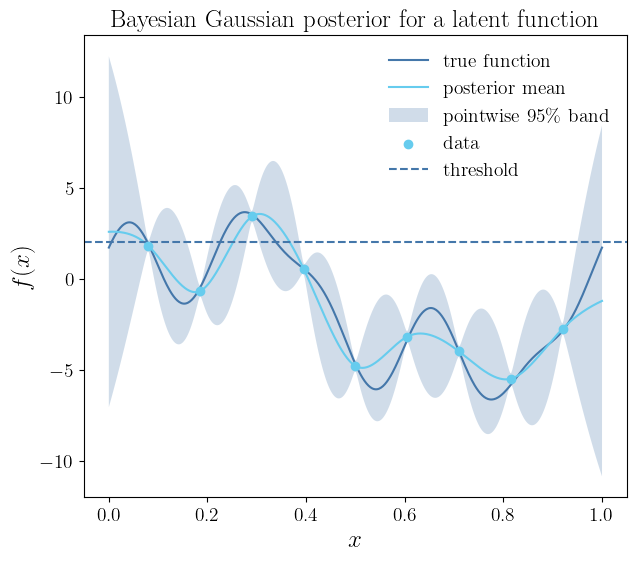

In [19]:
post_sd = np.sqrt(np.diag(post_cov))

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(t_plot, f_true(t_plot), label="true function")
ax.plot(t_plot, post_mean_plot, label="posterior mean")
ax.fill_between(
    t_plot,
    post_mean_plot - 1.96 * post_sd_plot,
    post_mean_plot + 1.96 * post_sd_plot,
    alpha=0.25,
    label="pointwise 95\% band",
)
ax.scatter(x_obs, y_obs, zorder=5, label="data")
ax.axhline(threshold, linestyle="--", label="threshold")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Bayesian Gaussian posterior for a latent function")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("posterior_gp_example")
plt.show()

# Quantity of interest: posterior probability that the curve is not far above the threshhold

## Sequences

In [20]:
sequences = {
    "iid": {
        "label": "IID MC",
        "distribution": lambda reps=None: qp.IIDStdUniform(d_grid, replications=reps),
        "color": colors["blue"],
        "linestyle": "-",
        "alpha": 0.12,
    },
    "sobol": {
        "label": "Sobol'",
        "distribution": lambda reps=None: qp.Sobol(d_grid, randomize=True, replications=reps),
        "color": colors["green"],
        "linestyle": "--",
        "alpha": 0.22,
    },
    "lattice": {
        "label": "Lattice",
        "distribution": lambda reps=None: qp.Lattice(d_grid, randomize=True, replications=reps),
        "color": colors["red"],
        "linestyle": "-.",
        "alpha": 0.18,
    },
    "halton": {
        "label": "Halton",
        "distribution": lambda reps=None: qp.Halton(d_grid, randomize=True, replications=reps),
        "color": colors["purple"],
        "linestyle": ":",
        "alpha": 0.18,
    },
    "kronecker": {
        "label": "Kronecker",
        "distribution": lambda reps=None: qp.Kronecker(d_grid, randomize=True, replications=reps),
        "color": colors["yellow"],
        "linestyle": "-",
        "alpha": 0.25,
    },
}

## Make posterior measure

In [21]:
def make_posterior_measure(distribution, decomp_type="PCA"):
    return qp.Gaussian(
        distribution,
        mean=post_mean,
        covariance=post_cov,
        decomp_type=decomp_type,   # "PCA" or "Cholesky"
    )

## Integrand loss and penalty function

In [22]:
def local_loss(g):
    return np.maximum(g - threshold, 0.0)**2

def spatial_risk(f_samples):
    return np.trapezoid(local_loss(f_samples), x=t_grid, axis=-1)

def risk_integrand_g(f_samples):
    J = spatial_risk(f_samples)
    return J**2

## Beginning of the transforms dictionary

In [23]:
transforms = {
    "chol": {
        "label": "Posterior Gaussian, Cholesky",
        "short_label": "Cholesky",
        "decomp_type": "Cholesky",
        "integrand": risk_integrand_g,
        "savefig_suffix": "chol",
    },
    "pca": {
        "label": "Posterior Gaussian, PCA",
        "short_label": "PCA",
        "decomp_type": "PCA",
        "integrand": risk_integrand_g,
        "savefig_suffix": "pca",
    },
}

transform_key = "pca"
transform = transforms[transform_key]

## First direct integrand Monte Carlo and Sobol' checks

In [24]:
def check_transform_estimates(transform_key, n=2**12, d_grid=d_grid):
    transform = transforms[transform_key]
    integrand = transform["integrand"]
    decomp_type = transform["decomp_type"]

    iid_measure = make_posterior_measure(
        sequences["iid"]["distribution"](),
        decomp_type=decomp_type,
    )

    vals = np.asarray(integrand(iid_measure(n))).reshape(-1)
    mc_sol = vals.mean()
    mc_err = 1.96 * vals.std(ddof=1) / math.sqrt(vals.size)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", MaxSamplesWarning)

        sobol_g_measure = make_posterior_measure(
            sequences["sobol"]["distribution"](),
            decomp_type=decomp_type,
        )

        sobol_g_sol, sobol_g_data = qp.CubQMCNetG(
            qp.CustomFun(
                sobol_g_measure,
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n,
            n_limit=n,
        ).integrate()

        clt_rep = 2**4

        sobol_clt_base = qp.Sobol(
            d_grid,
            randomize=True,
            replications=clt_rep,
        )

        sobol_clt_measure = make_posterior_measure(
            sequences["sobol"]["distribution"](reps=clt_rep),
            decomp_type=decomp_type,
        )

        sobol_clt_sol, sobol_clt_data = qp.CubQMCRepStudentT(
            qp.CustomFun(
                sobol_clt_measure,
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n,
            n_limit=n * clt_rep,
        ).integrate()

    sobol_g_err = sobol_g_data.comb_bound_diff / 2
    sobol_clt_err = sobol_clt_data.comb_bound_diff / 2

    message = (
        f"For the {transform['label']}\n"
        f"Based on n = {n} samples and d = {d_grid} discretization\n"
        f"IID MC:  {mc_sol:.5f} +/- {mc_err:.5f}\n"
        f"Sobol' G:  {sobol_g_sol:.5f} +/- {sobol_g_err:.5f}  "
        f"(CubQMCNetG bound)\n"
        f"Sobol' CLT:  {sobol_clt_sol:.5f} +/- {sobol_clt_err:.5f}  "
        f"(CubQMCRepStudentT bound)"
    )
    
    results = {
        "transform": transform["short_label"],
        "n": n,
        "message": message,
        "mc_sol": mc_sol,
        "mc_err": mc_err,
        "sobol_g_sol": sobol_g_sol,
        "sobol_g_err": sobol_g_err,
        "sobol_g_data": sobol_g_data,
        "sobol_clt_sol": sobol_clt_sol,
        "sobol_clt_err": sobol_clt_err,
        "sobol_clt_data": sobol_clt_data,
    }

    transforms[transform_key]["check"] = results  

    return results

check_transform_estimates(transform_key)
print(transforms[transform_key]["check"]["message"]) 

For the Posterior Gaussian, PCA
Based on n = 4096 samples and d = 64 discretization
IID MC:  1.58993 +/- 0.14384
Sobol' G:  1.64655 +/- 0.01883  (CubQMCNetG bound)
Sobol' CLT:  1.64392 +/- 0.00628  (CubQMCRepStudentT bound)


In [25]:
transform_key = "chol"
transform = transforms[transform_key]
check_transform_estimates(transform_key)
print(transforms[transform_key]["check"]["message"]) 

For the Posterior Gaussian, Cholesky
Based on n = 4096 samples and d = 64 discretization
IID MC:  1.62844 +/- 0.13673
Sobol' G:  1.66947 +/- 0.01647  (CubQMCNetG bound)
Sobol' CLT:  1.64246 +/- 0.01527  (CubQMCRepStudentT bound)


## Randomized replicate comparison: MC versus QMC

### Parameters for the replications

In [26]:
n = 2**12 #max sample size for benchmarks
r = 100 #number of replications
n_min_plt=2**7  #min sample size for plots 
fill_hw_default = 0.25 #half-width of band
transform_key = "pca"
transform = transforms[transform_key]

### Helper functions for benchmarks

In [27]:
def replicate_running_means(sequence, transform, n, reps=r):
    measure = make_posterior_measure(
        sequence["distribution"](reps=reps),
        decomp_type=transform["decomp_type"],
    )
    
    x = measure(n)
    
    if x.ndim == 2:
        x = x.reshape(1, *x.shape)

    r_actual, n_actual, d_actual = x.shape
    assert d_actual == d_grid

    vals = transform["integrand"](
        x.reshape(r_actual * n_actual, -1)
    )
    vals = np.asarray(vals).reshape(r_actual, n_actual)

    return np.cumsum(vals, axis=1) / np.arange(1, n_actual + 1)

def plot_running_band(
    ax,
    running,
    label=None,
    color=None,
    fill_hw=fill_hw_default,
    linestyle="-",
    linewidth=2,
    alpha=0.18,
    n_min_plot=100,
):
    k = np.arange(1, running.shape[1] + 1)
    mask = k >= n_min_plot

    center = running.mean(axis=0)
    qlo = np.quantile(running, 0.5-fill_hw, axis=0)
    qup = np.quantile(running, 0.5+fill_hw, axis=0)

    ax.plot(
        k[mask],
        center[mask],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
    )

    ax.fill_between(
        k[mask],
        qlo[mask],
        qup[mask],
        color=color,
        alpha=alpha,
    )

def plot_running_sequences(
    running,
    sequences,
    title="Running estimates across randomized replicates",
    ylabel="running estimate",
    n_min_plot=100,
    fill_hw=fill_hw_default,
    figsize=(7, 5),
    savefig=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    for key, sequence in sequences.items():
        plot_running_band(
            ax,
            running[key],
            label=sequence["label"],
            color=sequence["color"],
            linestyle=sequence["linestyle"],
            alpha=sequence["alpha"],
            n_min_plot=n_min_plot,
            fill_hw=fill_hw,
        )

    n_max_plot = next(iter(running.values())).shape[1]

    ax.set_xscale("log")
    xticks = 2**np.arange(6, 20)
    xticks = xticks[(xticks >= n_min_plot) & (xticks <= n_max_plot)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x}" for x in xticks])

    ax.set_xlim(left=n_min_plot, right=n_max_plot)
    ax.set_xlabel("number of samples")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best")

    if savefig is not None and nb.SAVEFIGS:
        nb.savefig(savefig)

    plt.show()
    
def summarize_running(running, sequences, transform):
    iid_key = next(
        key for key, sequence in sequences.items()
        if "IID" in sequence["label"]
    )

    iid_sd = running[iid_key][:, -1].std(ddof=1)

    rows = []

    for key, sequence in sequences.items():
        final_sd = running[key][:, -1].std(ddof=1)

        rows.append({
            "sequence": sequence["label"],
            f"{transform['short_label']} final_sd": final_sd,
            f"{transform['short_label']} sd_ratio_vs_iid": final_sd / iid_sd,
        })

    return pd.DataFrame(rows)

def run_transform_benchmark(
    transform_key,
    n,
    reps=r,
    n_min_plot=n_min_plt,
    fill_hw=fill_hw_default,
):
    transform = transforms[transform_key]

    running = {}

    for key, sequence in sequences.items():
        running[key] = replicate_running_means(
            sequence=sequence,
            transform=transform,
            n=n,
            reps=reps,
        )

    plot_running_sequences(
        running=running,
        sequences=sequences,
        title=f"{transform['label']}: running estimates",
        n_min_plot=n_min_plot,
        fill_hw=fill_hw,
        savefig=f"running_estimates_{transform['savefig_suffix']}_sequences",
    )

    summary = summarize_running(
        running=running,
        sequences=sequences,
        transform=transform,
    )

    transforms[transform_key]["running"] = running
    transforms[transform_key]["summary"] = summary

    return running, summary

### Run PCA benchmarks

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


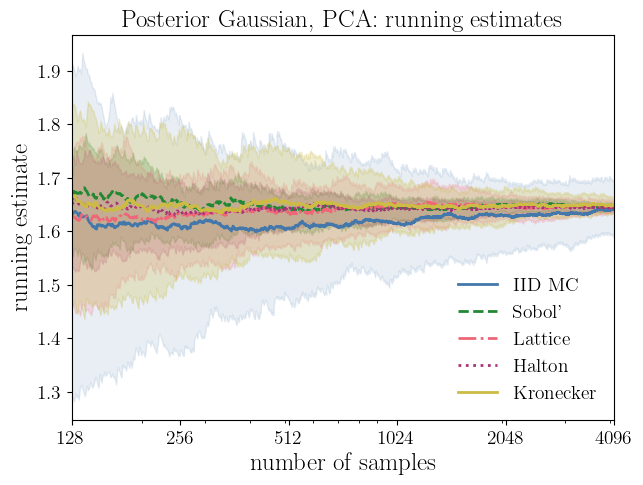

,sequence,PCA final_sd,PCA sd_ratio_vs_iid
0,IID MC,0.083632,1.000000
1,Sobol',0.009148,0.109378
2,Lattice,0.020613,0.246474
3,Halton,0.011359,0.135825
4,Kronecker,0.023074,0.275899


In [28]:
running, summary = run_transform_benchmark(
    transform_key,
    n=n,
    n_min_plot=n_min_plt,
)

transforms[transform_key]["summary"]

### Run benchmarks for Cholesky

/Users/fredjhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


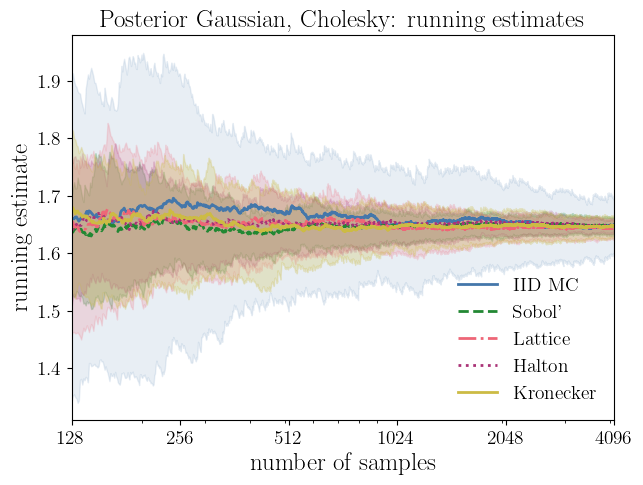

,sequence,Cholesky final_sd,Cholesky sd_ratio_vs_iid
0,IID MC,0.073946,1.000000
1,Sobol',0.019533,0.264153
2,Lattice,0.025924,0.350580
3,Halton,0.018546,0.250806
4,Kronecker,0.026355,0.356411


In [29]:
transform_key = "chol"
transform = transforms[transform_key]
running, summary = run_transform_benchmark(
    transform_key,
    n=n,
    n_min_plot=n_min_plt,
)

transforms[transform_key]["summary"]

In [30]:
summary_all = transforms["pca"]["summary"].merge(
    transforms["chol"]["summary"],
    on="sequence",
    how="outer",
)

summary_all

,sequence,PCA final_sd,PCA sd_ratio_vs_iid,Cholesky final_sd,Cholesky sd_ratio_vs_iid
0,Halton,0.011359,0.135825,0.018546,0.250806
1,IID MC,0.083632,1.000000,0.073946,1.000000
2,Kronecker,0.023074,0.275899,0.026355,0.356411
3,Lattice,0.020613,0.246474,0.025924,0.350580
4,Sobol',0.009148,0.109378,0.019533,0.264153
